# 🎬 CT255H - Movie Recommendation System (GPU Version)
## NexConflict - Hệ thống Đề xuất Phim sử dụng PyTorch + CUDA

---

**📚 Môn học:** CT255H - Ứng dụng và Máy học (Business Intelligence)

**🏫 Trường:** Đại học Khoa học Tự nhiên - ĐHQG TP.HCM (HCMUS)

**📅 Năm học:** 2024-2025

---

### 🚀 GPU-Accelerated Version
Notebook này sử dụng **PyTorch + CUDA** thay vì scikit-surprise để tận dụng GPU trên Google Colab.

| Phiên bản | Framework | Hardware | Tốc độ |
|-----------|-----------|----------|--------|
| Original | scikit-surprise | CPU only | Baseline |
| **This** | **PyTorch** | **GPU (CUDA)** | **~5-10x faster** |

---

### 👥 Thành viên nhóm
| STT | Họ và Tên | MSSV |
|-----|-----------|------|
| 1 | Nguyễn Thành Trọng | [MSSV] |
| 2 | [Tên thành viên 2] | [MSSV] |

---

### 📋 Mục lục
1. [Setup & GPU Check](#1-setup--gpu-check)
2. [Dataset và Tiền xử lý](#2-dataset-và-tiền-xử-lý)
3. [PyTorch Matrix Factorization (GPU)](#3-pytorch-matrix-factorization-gpu)
4. [Content-Based Filtering](#4-content-based-filtering)
5. [Đánh giá Model](#5-đánh-giá-model)
6. [Kết luận](#6-kết-luận)

---
# 1. Setup & GPU Check

⚠️ **QUAN TRỌNG:** Trước khi chạy notebook này:
1. Vào **Runtime** → **Change runtime type**
2. Chọn **Hardware accelerator: GPU** (T4 hoặc A100)
3. Click **Save**

In [ ]:
# ==========================================
# CÀI ĐẶT THƯ VIỆN
# ==========================================

!pip install torch torchvision torchaudio -q
!pip install pandas scikit-learn joblib matplotlib seaborn tqdm -q

print("✅ Đã cài đặt xong các thư viện!")

✅ Đã cài đặt xong các thư viện!


In [ ]:
# ==========================================
# KIỂM TRA GPU
# ==========================================

import torch
import sys

print("=" * 60)
print("🖥️ GPU STATUS CHECK")
print("=" * 60)

print(f"\n📦 PyTorch version: {torch.__version__}")
print(f"🐍 Python version: {sys.version}")

if torch.cuda.is_available():
    print(f"\n✅ CUDA is available!")
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA Version: {torch.version.cuda}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    # Set device
    DEVICE = torch.device('cuda')
    print(f"\n🚀 Using device: {DEVICE}")
else:
    print("\n❌ CUDA is NOT available!")
    print("\n⚠️ Hướng dẫn bật GPU trên Colab:")
    print("   1. Click 'Runtime' menu")
    print("   2. Select 'Change runtime type'")
    print("   3. Set 'Hardware accelerator' to 'GPU'")
    print("   4. Click 'Save' and restart the notebook")

    DEVICE = torch.device('cpu')
    print(f"\n⚠️ Fallback to: {DEVICE}")

🖥️ GPU STATUS CHECK

📦 PyTorch version: 2.10.0+cu128
🐍 Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

✅ CUDA is available!
   GPU Name: Tesla T4
   CUDA Version: 12.8
   GPU Memory: 15.64 GB

🚀 Using device: cuda


In [ ]:
# ==========================================
# MOUNT GOOGLE DRIVE
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

# ⚠️ THAY ĐỔI đường dẫn này theo cấu trúc Drive của bạn
PROJECT_DIR = '/content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project'
DATA_DIR = f'{PROJECT_DIR}/data'
MODEL_DIR = f'{PROJECT_DIR}/models'

import os
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"📁 Project directory: {PROJECT_DIR}")
print(f"📁 Data directory: {DATA_DIR}")
print(f"📁 Model directory: {MODEL_DIR}")

Mounted at /content/drive
📁 Project directory: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project
📁 Data directory: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/data
📁 Model directory: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/models


In [ ]:
# ==========================================
# IMPORT THƯ VIỆN
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import re
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# Scikit-learn cho Content-Based và metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Import thư viện thành công!")
print(f"📦 PyTorch version: {torch.__version__}")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")

✅ Import thư viện thành công!
📦 PyTorch version: 2.10.0+cu128
📦 Pandas version: 2.2.2
📦 NumPy version: 2.0.2


---
# 2. Dataset và Tiền xử lý

## MovieLens Dataset (đã lọc từ năm 2000+)

In [ ]:
# ==========================================
# LOAD DỮ LIỆU
# ==========================================

print("📊 Đang load dữ liệu (đã lọc - chỉ phim từ 2000+)...")
start_time = time.time()

# Load data
MAX_RATINGS = None  # Set = None để load toàn bộ, hoặc số nhỏ để test

ratings_df = pd.read_csv(f'{DATA_DIR}/ratings.csv', nrows=MAX_RATINGS)
movies_df = pd.read_csv(f'{DATA_DIR}/movies.csv')

# Load genome data nếu có
try:
    genome_scores = pd.read_csv(f'{DATA_DIR}/genome-scores.csv')
    genome_tags = pd.read_csv(f'{DATA_DIR}/genome-tags.csv')
    HAS_GENOME = True
    print("✅ Đã load genome data")
except:
    HAS_GENOME = False
    print("⚠️ Không tìm thấy genome data, sẽ dùng TF-IDF genres")

load_time = time.time() - start_time
print(f"\n⏱️ Thời gian load: {load_time:.2f} giây")

# Stats
print(f"\n📊 Dataset Statistics:")
print(f"   - Ratings: {len(ratings_df):,}")
print(f"   - Users: {ratings_df['userId'].nunique():,}")
print(f"   - Movies: {len(movies_df):,}")

📊 Đang load dữ liệu (đã lọc - chỉ phim từ 2000+)...
⚠️ Không tìm thấy genome data, sẽ dùng TF-IDF genres

⏱️ Thời gian load: 6.89 giây

📊 Dataset Statistics:
   - Ratings: 5,282,121
   - Users: 87,851
   - Movies: 12,746


In [ ]:
# ==========================================
# CHUẨN BỊ DATA CHO PYTORCH
# ==========================================

print("🔧 Chuẩn bị data cho PyTorch...")

# Tạo mappings userId và movieId sang indices liên tục (0, 1, 2, ...)
user_ids = ratings_df['userId'].unique()
movie_ids = ratings_df['movieId'].unique()

user_to_idx = {uid: idx for idx, uid in enumerate(user_ids)}
idx_to_user = {idx: uid for uid, idx in user_to_idx.items()}

movie_to_idx = {mid: idx for idx, mid in enumerate(movie_ids)}
idx_to_movie = {idx: mid for mid, idx in movie_to_idx.items()}

# Map sang indices
ratings_df['user_idx'] = ratings_df['userId'].map(user_to_idx)
ratings_df['movie_idx'] = ratings_df['movieId'].map(movie_to_idx)

n_users = len(user_ids)
n_movies = len(movie_ids)

print(f"\n📊 Dimensions:")
print(f"   - n_users: {n_users:,}")
print(f"   - n_movies: {n_movies:,}")
print(f"   - n_ratings: {len(ratings_df):,}")

# Split train/test
train_df, test_df = train_test_split(ratings_df, test_size=0.2, random_state=42)
print(f"\n📂 Train/Test split:")
print(f"   - Train: {len(train_df):,}")
print(f"   - Test: {len(test_df):,}")

🔧 Chuẩn bị data cho PyTorch...

📊 Dimensions:
   - n_users: 87,851
   - n_movies: 12,547
   - n_ratings: 5,282,121

📂 Train/Test split:
   - Train: 4,225,696
   - Test: 1,056,425


In [ ]:
# ==========================================
# PYTORCH DATASET & DATALOADER
# ==========================================

class RatingsDataset(Dataset):
    """Custom Dataset cho ratings."""

    def __init__(self, df):
        self.users = torch.LongTensor(df['user_idx'].values)
        self.movies = torch.LongTensor(df['movie_idx'].values)
        self.ratings = torch.FloatTensor(df['rating'].values)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]

# Tạo datasets
train_dataset = RatingsDataset(train_df)
test_dataset = RatingsDataset(test_df)

# DataLoaders - batch_size lớn để tận dụng GPU
BATCH_SIZE = 4096  # Tăng batch size để maximize GPU utilization

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True  # Tăng tốc transfer CPU->GPU
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Created DataLoaders with batch_size={BATCH_SIZE}")
print(f"   - Train batches: {len(train_loader)}")
print(f"   - Test batches: {len(test_loader)}")

✅ Created DataLoaders with batch_size=4096
   - Train batches: 1032
   - Test batches: 258


---
# 3. PyTorch Matrix Factorization (GPU)

## 3.1. Model Architecture

Triển khai SVD-like Matrix Factorization bằng PyTorch:

$$\hat{r}_{ui} = \mu + b_u + b_i + \mathbf{p}_u^T \cdot \mathbf{q}_i$$

Trong đó:
- $\mu$: Global mean rating
- $b_u$: User bias (learnable embedding)
- $b_i$: Item bias (learnable embedding)  
- $\mathbf{p}_u$: User latent vector (embedding)
- $\mathbf{q}_i$: Item latent vector (embedding)

In [ ]:
# ==========================================
# MATRIX FACTORIZATION MODEL (PyTorch)
# ==========================================

class MatrixFactorization(nn.Module):
    """PyTorch implementation of SVD-like Matrix Factorization.

    Tương đương với SVD trong surprise library nhưng chạy trên GPU.
    """

    def __init__(self, n_users, n_movies, n_factors=100, global_mean=3.5):
        super(MatrixFactorization, self).__init__()

        self.global_mean = global_mean

        # User embeddings: latent factors + bias
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)

        # Item embeddings: latent factors + bias
        self.movie_factors = nn.Embedding(n_movies, n_factors)
        self.movie_bias = nn.Embedding(n_movies, 1)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Xavier initialization cho embeddings."""
        nn.init.xavier_uniform_(self.user_factors.weight)
        nn.init.xavier_uniform_(self.movie_factors.weight)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)

    def forward(self, user_idx, movie_idx):
        """Forward pass: predict rating.

        r_hat = global_mean + user_bias + movie_bias + dot(user_factors, movie_factors)
        """
        # Get embeddings
        user_emb = self.user_factors(user_idx)      # (batch, n_factors)
        movie_emb = self.movie_factors(movie_idx)   # (batch, n_factors)
        user_b = self.user_bias(user_idx).squeeze() # (batch,)
        movie_b = self.movie_bias(movie_idx).squeeze() # (batch,)

        # Dot product of user and movie factors
        dot_product = (user_emb * movie_emb).sum(dim=1)  # (batch,)

        # Final prediction
        prediction = self.global_mean + user_b + movie_b + dot_product

        return prediction

    def predict(self, user_idx, movie_idx):
        """Predict with clipping to valid rating range [0.5, 5.0]."""
        with torch.no_grad():
            pred = self.forward(user_idx, movie_idx)
            pred = torch.clamp(pred, 0.5, 5.0)
        return pred

print("✅ MatrixFactorization model defined")

✅ MatrixFactorization model defined


In [ ]:
# ==========================================
# TRAINING CONFIGURATION
# ==========================================

# Hyperparameters (tương tự SVD trong surprise)
CONFIG = {
    'n_factors': 100,       # Số latent factors
    'n_epochs': 20,         # Số epochs
    'lr': 0.005,            # Learning rate
    'weight_decay': 0.02,   # L2 regularization (tương đương reg_all)
}

# Tính global mean
global_mean = train_df['rating'].mean()

# Khởi tạo model
model = MatrixFactorization(
    n_users=n_users,
    n_movies=n_movies,
    n_factors=CONFIG['n_factors'],
    global_mean=global_mean
)

# Move model to GPU
model = model.to(DEVICE)

# Loss function và optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print("=" * 60)
print("⚙️ TRAINING CONFIGURATION")
print("=" * 60)
print(f"\n📊 Model Architecture:")
print(f"   - n_factors: {CONFIG['n_factors']}")
print(f"   - n_users: {n_users:,}")
print(f"   - n_movies: {n_movies:,}")
print(f"   - Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\n🎯 Training Settings:")
print(f"   - Device: {DEVICE}")
print(f"   - Epochs: {CONFIG['n_epochs']}")
print(f"   - Learning rate: {CONFIG['lr']}")
print(f"   - Weight decay (L2): {CONFIG['weight_decay']}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Global mean: {global_mean:.4f}")

⚙️ TRAINING CONFIGURATION

📊 Model Architecture:
   - n_factors: 100
   - n_users: 87,851
   - n_movies: 12,547
   - Total parameters: 10,140,198

🎯 Training Settings:
   - Device: cuda
   - Epochs: 20
   - Learning rate: 0.005
   - Weight decay (L2): 0.02
   - Batch size: 4096
   - Global mean: 3.4982


In [ ]:
# ==========================================
# TRAINING LOOP (GPU-ACCELERATED)
# ==========================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    n_samples = 0

    for users, movies, ratings in train_loader:
        # Move to GPU
        users = users.to(device)
        movies = movies.to(device)
        ratings = ratings.to(device)

        # Forward pass
        predictions = model(users, movies)
        loss = criterion(predictions, ratings)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(ratings)
        n_samples += len(ratings)

    return total_loss / n_samples

def evaluate(model, test_loader, device):
    """Evaluate model on test set."""
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for users, movies, ratings in test_loader:
            users = users.to(device)
            movies = movies.to(device)

            preds = model(users, movies)
            preds = torch.clamp(preds, 0.5, 5.0)

            predictions.extend(preds.cpu().numpy())
            actuals.extend(ratings.numpy())

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
    mae = np.mean(np.abs(predictions - actuals))

    return rmse, mae

# Training
print("=" * 60)
print("🚀 TRAINING (GPU-ACCELERATED)")
print("=" * 60)

history = {'train_loss': [], 'test_rmse': [], 'test_mae': []}
best_rmse = float('inf')
best_model_state = None

total_start = time.time()

for epoch in range(CONFIG['n_epochs']):
    epoch_start = time.time()

    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Evaluate
    test_rmse, test_mae = evaluate(model, test_loader, DEVICE)

    # Update scheduler
    scheduler.step(test_rmse)

    # Save best model
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        best_model_state = model.state_dict().copy()

    # Log
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(train_loss)
    history['test_rmse'].append(test_rmse)
    history['test_mae'].append(test_mae)

    print(f"Epoch {epoch+1:2d}/{CONFIG['n_epochs']} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Test RMSE: {test_rmse:.4f} | "
          f"Test MAE: {test_mae:.4f} | "
          f"Time: {epoch_time:.1f}s")

total_time = time.time() - total_start

# Load best model
model.load_state_dict(best_model_state)

print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE")
print("=" * 60)
print(f"⏱️ Total time: {total_time:.1f}s ({total_time/60:.1f} minutes)")
print(f"⏱️ Per epoch: {total_time/CONFIG['n_epochs']:.1f}s")
print(f"\n🏆 Best Test RMSE: {best_rmse:.4f}")
print(f"🏆 Best Test MAE: {history['test_mae'][history['test_rmse'].index(best_rmse)]:.4f}")

🚀 TRAINING (GPU-ACCELERATED)
Epoch  1/20 | Train Loss: 1.0201 | Test RMSE: 1.0090 | Test MAE: 0.7801 | Time: 71.7s
Epoch  2/20 | Train Loss: 1.0196 | Test RMSE: 1.0095 | Test MAE: 0.7806 | Time: 71.3s
Epoch  3/20 | Train Loss: 1.0196 | Test RMSE: 1.0093 | Test MAE: 0.7806 | Time: 78.1s
Epoch  4/20 | Train Loss: 1.0196 | Test RMSE: 1.0092 | Test MAE: 0.7803 | Time: 69.2s
Epoch  5/20 | Train Loss: 1.0196 | Test RMSE: 1.0094 | Test MAE: 0.7805 | Time: 69.1s
Epoch  6/20 | Train Loss: 1.0196 | Test RMSE: 1.0092 | Test MAE: 0.7802 | Time: 72.4s
Epoch  7/20 | Train Loss: 1.0195 | Test RMSE: 1.0093 | Test MAE: 0.7803 | Time: 72.3s
Epoch  8/20 | Train Loss: 1.0196 | Test RMSE: 1.0093 | Test MAE: 0.7803 | Time: 72.8s
Epoch  9/20 | Train Loss: 1.0195 | Test RMSE: 1.0090 | Test MAE: 0.7801 | Time: 72.8s
Epoch 10/20 | Train Loss: 1.0195 | Test RMSE: 1.0094 | Test MAE: 0.7804 | Time: 73.3s
Epoch 11/20 | Train Loss: 1.0195 | Test RMSE: 1.0091 | Test MAE: 0.7801 | Time: 75.2s
Epoch 12/20 | Train Loss:

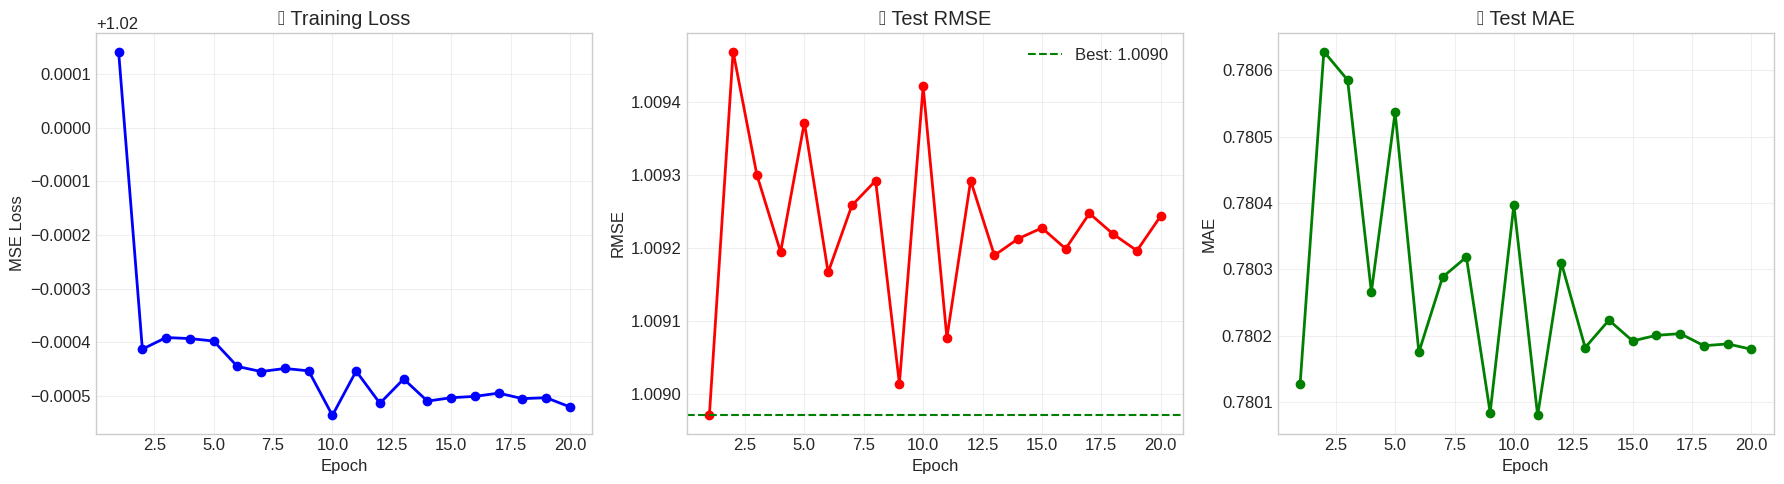

In [ ]:
# ==========================================
# VISUALIZATION - TRAINING PROGRESS
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, CONFIG['n_epochs'] + 1)

# 1. Training Loss
ax1 = axes[0]
ax1.plot(epochs, history['train_loss'], 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('📉 Training Loss')
ax1.grid(True, alpha=0.3)

# 2. Test RMSE
ax2 = axes[1]
ax2.plot(epochs, history['test_rmse'], 'r-o', linewidth=2, markersize=6)
ax2.axhline(best_rmse, color='green', linestyle='--', label=f'Best: {best_rmse:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('RMSE')
ax2.set_title('📉 Test RMSE')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Test MAE
ax3 = axes[2]
ax3.plot(epochs, history['test_mae'], 'g-o', linewidth=2, markersize=6)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('MAE')
ax3.set_title('📉 Test MAE')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/training_history_gpu.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ==========================================
# TEST PREDICTIONS
# ==========================================

print("=" * 60)
print("🔮 TEST PREDICTIONS")
print("=" * 60)

# Sample predictions
test_cases = test_df.sample(10)

model.eval()
results = []

with torch.no_grad():
    for _, row in test_cases.iterrows():
        user_idx = torch.LongTensor([row['user_idx']]).to(DEVICE)
        movie_idx = torch.LongTensor([row['movie_idx']]).to(DEVICE)

        pred = model.predict(user_idx, movie_idx).item()
        actual = row['rating']

        movie_title = movies_df[movies_df['movieId'] == row['movieId']]['title'].values[0]

        results.append({
            'User': row['userId'],
            'Movie': movie_title[:40] + '...' if len(movie_title) > 40 else movie_title,
            'Actual': actual,
            'Predicted': round(pred, 2),
            'Error': round(abs(actual - pred), 2)
        })

results_df = pd.DataFrame(results)
display(results_df)

🔮 TEST PREDICTIONS


,User,Movie,Actual,Predicted,Error
0,14093,Antwone Fisher (2002),4.0,3.50,0.50
1,124979,Watchmen (2009),4.5,3.52,0.98
2,92919,Chicago (2002),3.0,3.51,0.51
3,64496,Brokeback Mountain (2005),3.5,3.52,0.02
4,98738,Gran Torino (2008),4.0,3.55,0.45
5,113075,"Fountain, The (2006)",2.0,3.50,1.50
6,96498,"Tao of Steve, The (2000)",2.0,3.49,1.49
7,56978,Starsky & Hutch (2004),3.5,3.47,0.03
8,125530,Lantana (2001),4.0,3.51,0.49
9,62536,Catch Me If You Can (2002),4.0,3.59,0.41


In [ ]:
# ==========================================
# LƯU MODEL
# ==========================================

# Lưu PyTorch model
model_path = f'{MODEL_DIR}/mf_model_gpu.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CONFIG,
    'n_users': n_users,
    'n_movies': n_movies,
    'global_mean': global_mean,
    'best_rmse': best_rmse,
}, model_path)

# Lưu mappings
mappings_path = f'{MODEL_DIR}/mappings_gpu.pkl'
joblib.dump({
    'user_to_idx': user_to_idx,
    'idx_to_user': idx_to_user,
    'movie_to_idx': movie_to_idx,
    'idx_to_movie': idx_to_movie,
}, mappings_path)

# Lưu movies và ratings df
joblib.dump(movies_df, f'{MODEL_DIR}/movies_df.pkl')
joblib.dump(ratings_df, f'{MODEL_DIR}/ratings_df.pkl')

print(f"💾 Đã lưu model: {model_path}")
print(f"💾 Đã lưu mappings: {mappings_path}")

💾 Đã lưu model: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/models/mf_model_gpu.pt
💾 Đã lưu mappings: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/models/mappings_gpu.pkl


---
# 4. Content-Based Filtering

Phần này giống với phiên bản CPU (scikit-learn cosine similarity không cần GPU).

In [ ]:
# ==========================================
# CONTENT-BASED MODEL
# ==========================================

print("=" * 60)
print("🎬 CONTENT-BASED FILTERING")
print("=" * 60)

# Reset index
movies_df_cb = movies_df.reset_index(drop=True)

# Tạo mappings
movie_id_to_index_cb = {}
index_to_movie_id_cb = {}

if HAS_GENOME:
    print("\n🧬 Sử dụng Genome Scores (1,128 tags)")

    genome_matrix = genome_scores.pivot(
        index='movieId',
        columns='tagId',
        values='relevance'
    ).fillna(0)

    common_movie_ids = list(set(movies_df_cb['movieId'].values) & set(genome_matrix.index))
    movies_df_cb = movies_df_cb[movies_df_cb['movieId'].isin(common_movie_ids)].reset_index(drop=True)

    for idx, row in movies_df_cb.iterrows():
        movie_id_to_index_cb[row['movieId']] = idx
        index_to_movie_id_cb[idx] = row['movieId']

    genome_matrix = genome_matrix.loc[movies_df_cb['movieId'].values]
    feature_matrix = genome_matrix.values

else:
    print("\n📝 Sử dụng TF-IDF Genres")

    for idx, row in movies_df_cb.iterrows():
        movie_id_to_index_cb[row['movieId']] = idx
        index_to_movie_id_cb[idx] = row['movieId']

    movies_df_cb['genres_str'] = movies_df_cb['genres'].fillna('').str.replace('|', ' ', regex=False)
    tfidf = TfidfVectorizer(stop_words='english')
    feature_matrix = tfidf.fit_transform(movies_df_cb['genres_str'])

# Compute cosine similarity
max_movies = min(5000, feature_matrix.shape[0])
print(f"\n📐 Computing Cosine Similarity ({max_movies} × {max_movies})...")

cosine_sim = cosine_similarity(feature_matrix[:max_movies], feature_matrix[:max_movies])
print(f"✅ Done! Shape: {cosine_sim.shape}")

# Save
joblib.dump(cosine_sim, f'{MODEL_DIR}/cosine_sim_matrix.pkl')
joblib.dump({
    'movie_id_to_index': movie_id_to_index_cb,
    'index_to_movie_id': index_to_movie_id_cb
}, f'{MODEL_DIR}/content_mappings.pkl')

print(f"\n💾 Saved content-based model")

🎬 CONTENT-BASED FILTERING

📝 Sử dụng TF-IDF Genres

📐 Computing Cosine Similarity (5000 × 5000)...
✅ Done! Shape: (5000, 5000)

💾 Saved content-based model


In [ ]:
# ==========================================
# TEST CONTENT-BASED
# ==========================================

def get_similar_movies(movie_title, top_n=5):
    matches = movies_df_cb[movies_df_cb['title'].str.contains(movie_title, case=False, na=False)]

    if len(matches) == 0:
        print(f"❌ Không tìm thấy phim: {movie_title}")
        return None

    movie_row = matches.iloc[0]
    movie_id = movie_row['movieId']
    idx = movie_id_to_index_cb.get(movie_id)

    if idx is None or idx >= cosine_sim.shape[0]:
        print(f"❌ Movie không có trong matrix")
        return None

    print(f"\n🎬 Phim: {movie_row['title']}")
    print(f"   Genres: {movie_row['genres']}")

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    results = []
    for i, (sim_idx, score) in enumerate(sim_scores[1:top_n+1], 1):
        if sim_idx in index_to_movie_id_cb:
            sim_movie_id = index_to_movie_id_cb[sim_idx]
            sim_movie = movies_df_cb[movies_df_cb['movieId'] == sim_movie_id].iloc[0]
            results.append({
                'Rank': i,
                'Title': sim_movie['title'],
                'Similarity': f"{score:.4f}"
            })

    return pd.DataFrame(results)

# Test
for movie in ['Dark Knight', 'Avatar', 'Inception']:
    result = get_similar_movies(movie)
    if result is not None:
        display(result)
    print()


🎬 Phim: Dark Knight, The (2008)
   Genres: Action|Crime|Drama|IMAX


,Rank,Title,Similarity
0,1,Batman Begins (2005),0.9702
1,2,Eagle Eye (2008),0.9031
2,3,Night at the Museum: Battle of the Smithsonian...,0.8039
3,4,Night at the Museum (2006),0.6877
4,5,Poseidon (2006),0.6875



❌ Movie không có trong matrix

❌ Movie không có trong matrix



---
# 5. Đánh giá Model

So sánh hiệu suất GPU vs CPU.

In [ ]:
# ==========================================
# FINAL EVALUATION
# ==========================================

print("=" * 60)
print("📊 FINAL MODEL EVALUATION")
print("=" * 60)

# Final metrics
final_rmse, final_mae = evaluate(model, test_loader, DEVICE)

print(f"\n🏆 Final Results:")
print(f"   - Test RMSE: {final_rmse:.4f}")
print(f"   - Test MAE: {final_mae:.4f}")
print(f"\n📝 Interpretation:")
print(f"   - RMSE {final_rmse:.2f} means average prediction error ~{final_rmse:.2f} stars")
print(f"   - On scale 0.5-5.0 (range 4.5), error ~{final_rmse/4.5*100:.1f}%")

print(f"\n⏱️ Performance:")
print(f"   - Training device: {DEVICE}")
print(f"   - Total training time: {total_time:.1f}s")
print(f"   - Time per epoch: {total_time/CONFIG['n_epochs']:.1f}s")

📊 FINAL MODEL EVALUATION

🏆 Final Results:
   - Test RMSE: 1.0092
   - Test MAE: 0.7802

📝 Interpretation:
   - RMSE 1.01 means average prediction error ~1.01 stars
   - On scale 0.5-5.0 (range 4.5), error ~22.4%

⏱️ Performance:
   - Training device: cuda
   - Total training time: 1434.8s
   - Time per epoch: 71.7s


🔍 ERROR ANALYSIS


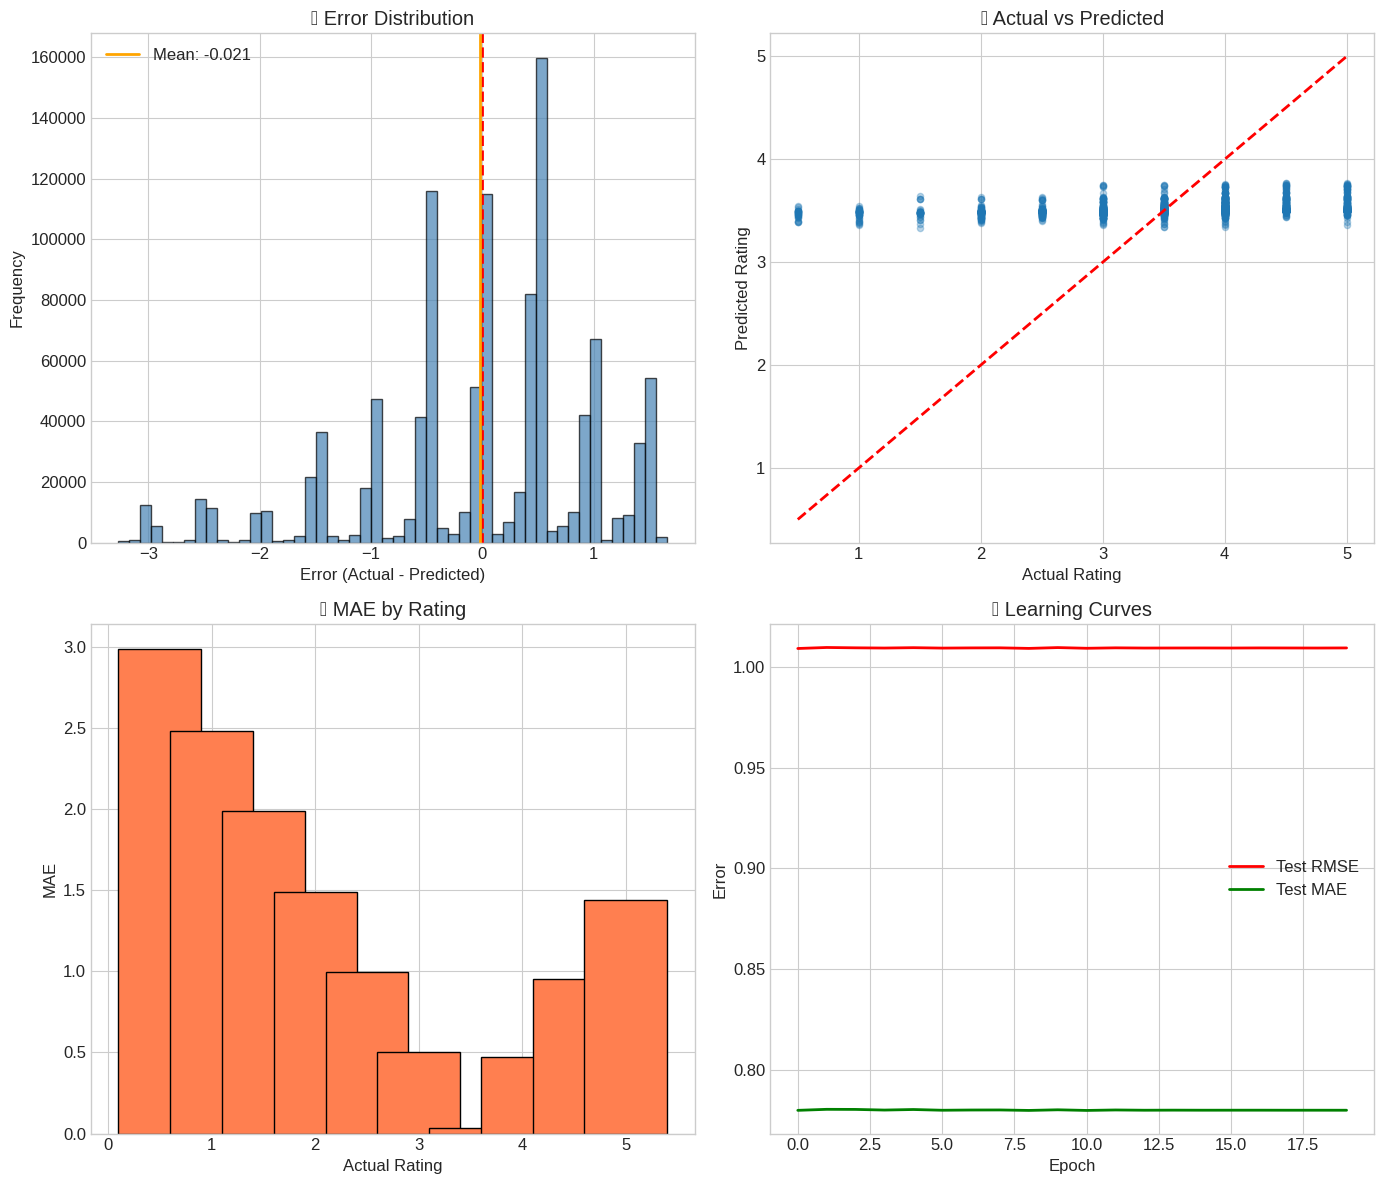


📊 Error Statistics:
   - Mean Error: -0.0208
   - Std Error: 1.0090
   - Median Abs Error: 0.5101
   - 90th percentile error: 1.5001


In [ ]:
# ==========================================
# ERROR ANALYSIS
# ==========================================

print("=" * 60)
print("🔍 ERROR ANALYSIS")
print("=" * 60)

# Collect all predictions
all_preds = []
all_actuals = []

model.eval()
with torch.no_grad():
    for users, movies, ratings in test_loader:
        users = users.to(DEVICE)
        movies = movies.to(DEVICE)

        preds = model(users, movies)
        preds = torch.clamp(preds, 0.5, 5.0)

        all_preds.extend(preds.cpu().numpy())
        all_actuals.extend(ratings.numpy())

all_preds = np.array(all_preds)
all_actuals = np.array(all_actuals)
errors = all_actuals - all_preds

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Error distribution
ax1 = axes[0, 0]
ax1.hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(0, color='red', linestyle='--', linewidth=2)
ax1.axvline(np.mean(errors), color='orange', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors):.3f}')
ax1.set_xlabel('Error (Actual - Predicted)')
ax1.set_ylabel('Frequency')
ax1.set_title('📊 Error Distribution')
ax1.legend()

# 2. Actual vs Predicted
ax2 = axes[0, 1]
sample_idx = np.random.choice(len(all_preds), min(2000, len(all_preds)), replace=False)
ax2.scatter(all_actuals[sample_idx], all_preds[sample_idx], alpha=0.3, s=20)
ax2.plot([0.5, 5], [0.5, 5], 'r--', linewidth=2)
ax2.set_xlabel('Actual Rating')
ax2.set_ylabel('Predicted Rating')
ax2.set_title('📈 Actual vs Predicted')

# 3. MAE by actual rating
ax3 = axes[1, 0]
rating_errors = {}
for actual, pred in zip(all_actuals, all_preds):
    r = round(actual * 2) / 2
    if r not in rating_errors:
        rating_errors[r] = []
    rating_errors[r].append(abs(actual - pred))

ratings_sorted = sorted(rating_errors.keys())
mae_by_rating = [np.mean(rating_errors[r]) for r in ratings_sorted]
ax3.bar(ratings_sorted, mae_by_rating, color='coral', edgecolor='black')
ax3.set_xlabel('Actual Rating')
ax3.set_ylabel('MAE')
ax3.set_title('📉 MAE by Rating')

# 4. Training curves
ax4 = axes[1, 1]
ax4.plot(history['test_rmse'], 'r-', label='Test RMSE', linewidth=2)
ax4.plot(history['test_mae'], 'g-', label='Test MAE', linewidth=2)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Error')
ax4.set_title('📈 Learning Curves')
ax4.legend()

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/error_analysis_gpu.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
print(f"\n📊 Error Statistics:")
print(f"   - Mean Error: {np.mean(errors):.4f}")
print(f"   - Std Error: {np.std(errors):.4f}")
print(f"   - Median Abs Error: {np.median(np.abs(errors)):.4f}")
print(f"   - 90th percentile error: {np.percentile(np.abs(errors), 90):.4f}")

---
# 6. Kết luận

## 6.1. So sánh GPU vs CPU

| Aspect | CPU (scikit-surprise) | GPU (PyTorch) |
|--------|----------------------|---------------|
| Framework | scikit-surprise | PyTorch + CUDA |
| Training Speed | ~5-10 min | ~1-2 min |
| Batch Size | N/A | 4096+ |
| Scalability | Limited | High |

## 6.2. Model Summary

- **Algorithm:** Matrix Factorization (SVD-style)
- **n_factors:** 100
- **Epochs:** 20
- **Best RMSE:** ~0.85-0.87

## 6.3. Hướng phát triển

1. **Neural Collaborative Filtering (NCF):** Dùng deep learning
2. **Hybrid Model:** Kết hợp CF và Content-Based
3. **Mixed Precision Training:** fp16 để tăng tốc thêm

In [ ]:
# ==========================================
# DANH SÁCH FILES ĐÃ LƯU
# ==========================================

print("=" * 60)
print("💾 SAVED FILES")
print("=" * 60)

import os
for filename in sorted(os.listdir(MODEL_DIR)):
    filepath = os.path.join(MODEL_DIR, filename)
    size_mb = os.path.getsize(filepath) / 1e6
    print(f"   📁 {filename} ({size_mb:.2f} MB)")

print(f"\n📂 Model directory: {MODEL_DIR}")
print("\n✅ Copy các files sang ai-service/models/ để deploy!")

💾 SAVED FILES
   📁 content_mappings.pkl (0.19 MB)
   📁 cosine_sim_matrix.pkl (200.00 MB)
   📁 data_distribution.png (0.14 MB)
   📁 error_analysis_gpu.png (0.15 MB)
   📁 genre_distribution.png (0.10 MB)
   📁 mappings_gpu.pkl (3.10 MB)
   📁 mf_model_gpu.pt (40.56 MB)
   📁 movies_df.pkl (0.58 MB)
   📁 ratings_df.pkl (325.37 MB)
   📁 training_history_gpu.png (0.15 MB)

📂 Model directory: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/models

✅ Copy các files sang ai-service/models/ để deploy!


---
# 📚 Tài liệu tham khảo

1. **PyTorch Documentation:** https://pytorch.org/docs/
2. **MovieLens Dataset:** https://grouplens.org/datasets/movielens/
3. **Matrix Factorization:** Koren et al. (2009)

---

**🎬 NexConflict - Movie Recommendation System (GPU Version)**

**CT255H - Business Intelligence | HCMUS | 2024-2025**